In [ ]:
import yfinance as yf
import pandas as pd
import openpyxl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [96]:
#1) Escolha uma periodicidade (por exemplo, mensal ou semanal) e liste as cotações de
#fechamento para um determinado período de tempo (por exemplo, 6 meses, 1 ano, 5 anos).
#Certifique-se de que você tenha pelo menos 30 observações de cada ação.

# 1. Lista de tickers corrigida (com '^' no S&P 500)
tickers = ["AAPL", "MSFT", "NVDA", "GOOGL", "META", "^GSPC"]

# 2. Download dos dados
# Use interval="1mo" para mensal ou interval="1wk" para semanal
precos = yf.download(
    tickers,
    start="2020-01-01",
    end="2026-07-31",
    interval="1d",  # Periodicidade mensal
    auto_adjust=True
)["Close"]

[*********************100%***********************]  6 of 6 completed


In [ ]:
# 1. Resetar o índice (se necessário)
precos = precos.reset_index()

# 2. Converter a data
precos["Date"] = pd.to_datetime(precos["Date"])

# 3. Criar a coluna do dia da semana (ANTES de definir 'Date' como índice)
precos["Weekday"] = precos["Date"].dt.day_name()

# 4. Definir 'Date' como índice
precos = precos.set_index("Date")

# 5. Identificar apenas as colunas numéricas (tickers)
colunas_tickers = [col for col in precos.columns if col != "Weekday"]

# 6.2. Calcular o retorno simples (percentual)
retorno_simples = precos[colunas_tickers].pct_change()

# 7. Adicionar o dia da semana nos DataFrames de retorno
retorno_simples["Weekday"] = precos["Weekday"]

# 8. Reordenar as colunas
cols_ordenadas = ["Weekday"] + colunas_tickers
precos = precos[cols_ordenadas]
retorno_simples = retorno_simples[cols_ordenadas]

In [ ]:
df = precos

# Garantir formato datetime no índice
df.index = pd.to_datetime(df.index)

# Remover a coluna 'Weekday' se ela existir
if "Weekday" in df.columns:
    df = df.drop(columns=["Weekday"])

# 2. Selecionar o último preço de cada semana (fechamento de sexta-feira)
precos_semanais = df.resample("W-FRI").last().dropna()

# 3. Calcular Retornos Semanais
# 3.1. Log-Retorno Semanal
log_retorno_semanal = np.log(
    precos_semanais / precos_semanais.shift(1)
).dropna()

# 3.2. Retorno Simples Semanal (percentual)
retorno_simples_semanal = precos_semanais.pct_change().dropna()

In [153]:
#3) Calcule o desvio padrão dos retornos para cada ação do item 2.

std_simples_semanal = retorno_simples_semanal.std()
std_simples_anual = std_simples_semanal * np.sqrt(52)

# 5. Criar DataFrame Exclusivo de Desvio Padrão
resumo_desvio_padrao = pd.DataFrame(
    {
        "Desvio Padrão Simples (Semanal)": std_simples_semanal,
        "Volatilidade Anualizada (Simples)": std_simples_anual
    }
) 

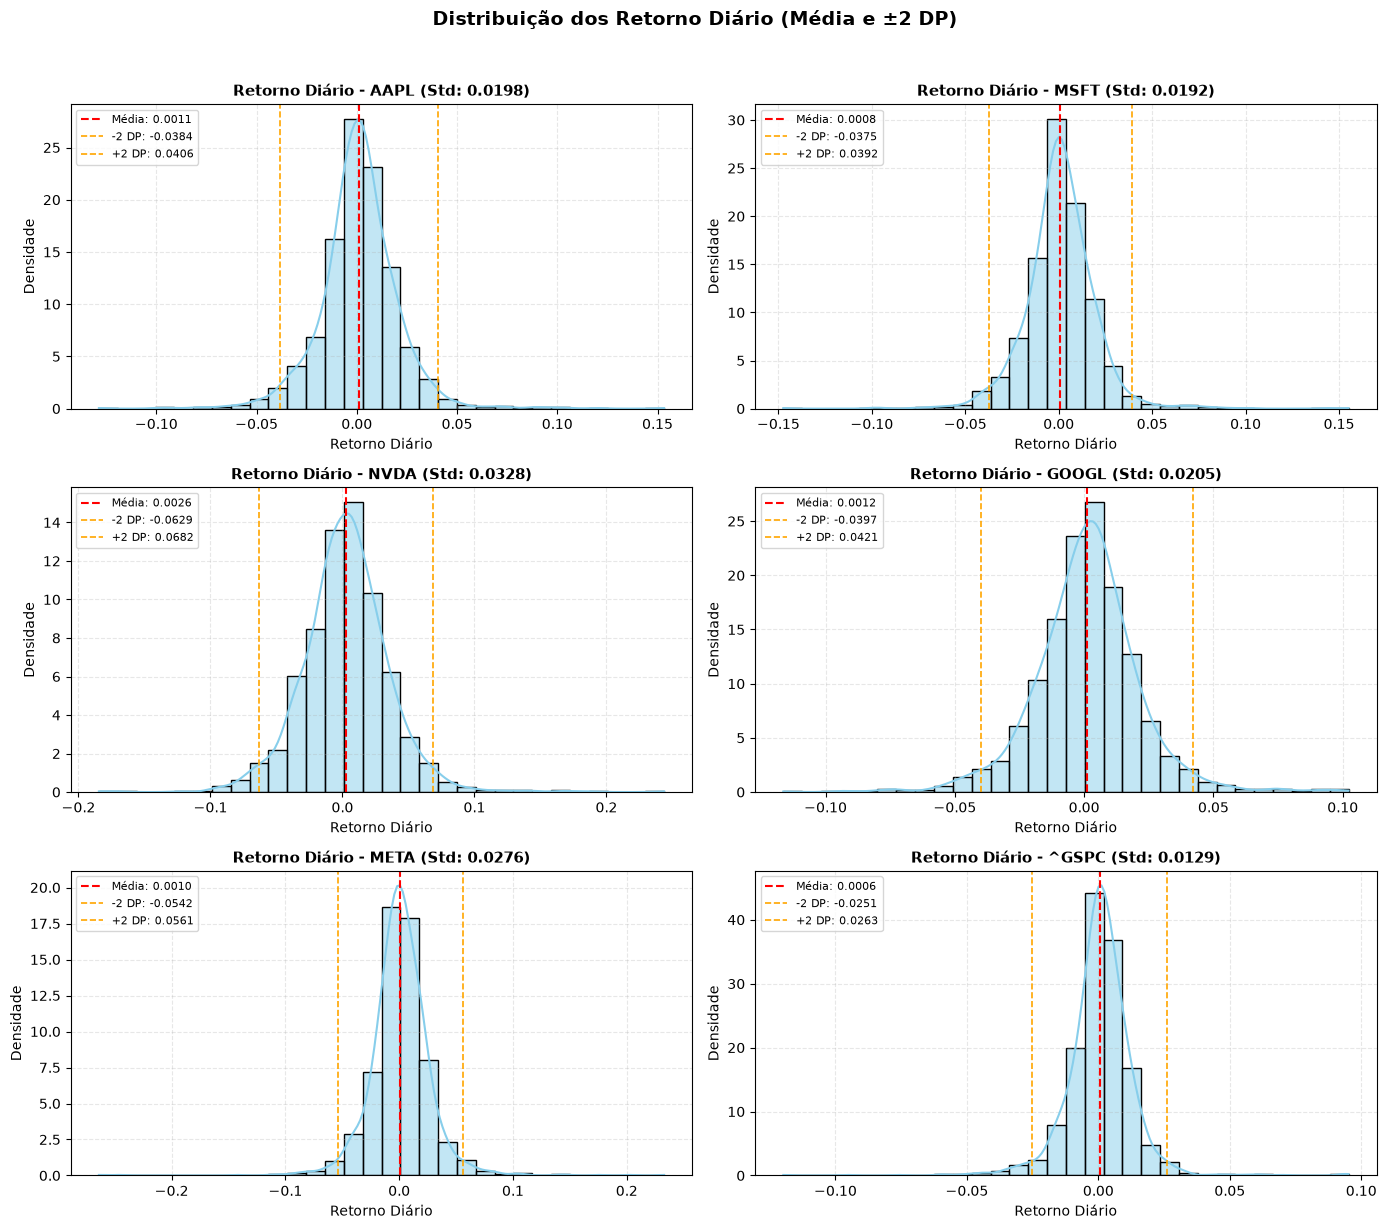

In [154]:
# Configurar a grade para exibir 2 gráficos por linha (2 colunas)
n_tickers = len(tickers)
ncols = 2
nrows = (n_tickers + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows))

# Garantir tratamento para matriz de eixos 1D / 2D
if n_tickers == 1:
    axes = np.array([axes])
else:
    axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    dados_retorno = retorno_simples[ticker].dropna()
    media_log = dados_retorno.mean()
    desvio_log = dados_retorno.std()

    # Histograma com Curva de Densidade (KDE)
    sns.histplot(
        dados_retorno,
        kde=True,
        ax=ax,
        color="skyblue",
        bins=30,
        stat="density",
    )

    # Linha da Média
    ax.axvline(
        media_log,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Média: {media_log:.4f}",
    )

    # Linhas de -2 DP e +2 DP
    ax.axvline(
        media_log - 2 * desvio_log,
        color="orange",
        linestyle="--",
        linewidth=1.2,
        label=f"-2 DP: {media_log - 2*desvio_log:.4f}",
    )
    ax.axvline(
        media_log + 2 * desvio_log,
        color="orange",
        linestyle="--",
        linewidth=1.2,
        label=f"+2 DP: {media_log + 2*desvio_log:.4f}",
    )

    # Configuração dos rótulos
    ax.set_title(
        f"Retorno Diário - {ticker} (Std: {desvio_log:.4f})",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel("Retorno Diário")
    ax.set_ylabel("Densidade")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.3)

# Deletar subplots vazios caso a quantidade de tickers seja ímpar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribuição dos Retorno Diário (Média e ±2 DP)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

In [ ]:
df_retornos = retorno_simples

ticker_indice = "^GSPC"

df_retornos = df_retornos.drop(columns=["Weekday"])

# ---------------------------------------------------------------------
# Lista de ações
# ---------------------------------------------------------------------
acoes = [
    c for c in df_retornos.columns
    if c not in [ticker_indice,"Weekday","Weekday2"]
]

# ---------------------------------------------------------------------
# Beta Geral
# ---------------------------------------------------------------------
var_mercado = df_retornos[ticker_indice].var()

betas_geral = {
    acao:
    df_retornos[acao].cov(df_retornos[ticker_indice]) /
    var_mercado
    for acao in acoes
}

df_betas_geral = (
    pd.DataFrame.from_dict(
        betas_geral,
        orient="index",
        columns=["Beta CAPM Geral"]
    )
)

# ---------------------------------------------------------------------
# Beta móvel de 252 dias
# ---------------------------------------------------------------------
janela = 252

var_movel = (
    df_retornos[ticker_indice]
    .rolling(window=janela, min_periods=janela)
    .var()
)

betas = {}

for acao in acoes:
    cov = (
        df_retornos[acao]
        .rolling(window=janela, min_periods=janela)
        .cov(df_retornos[ticker_indice])
    )
    betas[acao] = cov / var_movel

# Monta o DataFrame e remove as linhas vazias (as primeiras 251 linhas)
df_betas_diarios_movel = pd.DataFrame(
    betas, 
    index=df_retornos.index
).dropna(how="all")

In [ ]:
rf = 0.0468      # 4,68%
mrp = 0.0550     # 5,50%

df_capm = df_betas_geral.copy()

df_capm["CAPM"] = rf + df_capm["Beta CAPM Geral"] * mrp
# Em porcentagem
df_capm["CAPM (%)"] = df_capm["CAPM"] * 100

In [ ]:
# 1. Baixar o ticker ^TNX
tnx = yf.download("^TNX", start="2020-01-01", end="2026-07-30")["Close"]


# 2. O ^TNX vem cotado em porcentagem (ex: 4.68)
# Criar DataFrame e converter para decimal e depois para diária
df_rf = pd.DataFrame(tnx)
df_rf.columns = ["Rf_anual_pct"]

df_rf["Rf_anual"] = df_rf["Rf_anual_pct"].ffill() / 100
df_rf["Rf_diario"] = (1 + df_rf["Rf_anual"]) ** (1 / 252) - 1

In [ ]:
# ---------------------------------------------------------------------
# REGRESSÃO CAPM — RELATÓRIOS LADO A LADO EM UMA ÚNICA PLANILHA
# ---------------------------------------------------------------------

mercado_col = "^GSPC"
acoes = [col for col in df_retornos.columns if col != mercado_col]

nome_arquivo = "Resultados_regressões.xlsx"
nome_aba = "Regressões Ações"

with pd.ExcelWriter(nome_arquivo, engine="openpyxl") as writer:
    coluna_atual = 0  # Controla a posição inicial da coluna para cada ativo

    for acao in acoes:
        # 1. Preparar base limpa
        df_reg = pd.DataFrame(
            {
                "Y_excesso": df_retornos[acao] - df_rf["Rf_diario"],
                "X_excesso": df_retornos[mercado_col] - df_rf["Rf_diario"],
            }
        ).dropna()

        Y = df_reg["Y_excesso"]
        X = sm.add_constant(df_reg["X_excesso"])

        # 2. Ajustar Modelo OLS
        modelo = sm.OLS(Y, X).fit()

        # -------------------------------------------------------------
        # 3. EXTRAÇÃO DAS TABELAS NATIVAS DO EXCEL
        # -------------------------------------------------------------

        # A) Estatística de Regressão
        r_mult = np.sqrt(modelo.rsquared)
        df_estatisticas = pd.DataFrame(
            [
                ["R múltiplo", r_mult],
                ["R-Quadrado", modelo.rsquared],
                ["R-quadrado ajustado", modelo.rsquared_adj],
                ["Erro padrão", np.sqrt(modelo.mse_resid)],
                ["Observações", int(modelo.nobs)],
            ],
            columns=["Estatística de regressão", ""],
        )

        # B) Tabela ANOVA
        df_anova = pd.DataFrame(
            [
                [
                    "Regressão",
                    int(modelo.df_model),
                    modelo.ess,
                    modelo.mse_model,
                    modelo.fvalue,
                    modelo.f_pvalue,
                ],
                [
                    "Resíduo",
                    int(modelo.df_resid),
                    modelo.ssr,
                    modelo.mse_resid,
                    np.nan,
                    np.nan,
                ],
                [
                    "Total",
                    int(modelo.df_model + modelo.df_resid),
                    modelo.centered_tss,
                    np.nan,
                    np.nan,
                    np.nan,
                ],
            ],
            columns=["ANOVA", "gl", "SQ", "MQ", "F", "F de significação"],
        )

        # C) Coeficientes e Intervalos de Confiança
        conf_int = modelo.conf_int()
        df_coeficientes = pd.DataFrame(
            {
                "": ["Interseção", "Variável X 1"],
                "Coeficientes": modelo.params.values,
                "Erro padrão": modelo.bse.values,
                "Stat t": modelo.tvalues.values,
                "valor-P": modelo.pvalues.values,
                "95% inferior": conf_int.iloc[:, 0].values,
                "95% superior": conf_int.iloc[:, 1].values,
                "Inferior 95,0%": conf_int.iloc[:, 0].values,
                "Superior 95,0%": conf_int.iloc[:, 1].values,
            }
        )

        # -------------------------------------------------------------
        # 4. ESCREVER NO EXCEL NA MESMA PLANILHA (LADO A LADO)
        # -------------------------------------------------------------

        # Título do Ativo
        pd.DataFrame([[f"RESUMO DOS RESULTADOS — {acao}"]]).to_excel(
            writer,
            sheet_name=nome_aba,
            startrow=0,
            startcol=coluna_atual,
            index=False,
            header=False,
        )

        # Bloco Estatísticas
        df_estatisticas.to_excel(
            writer,
            sheet_name=nome_aba,
            startrow=2,
            startcol=coluna_atual,
            index=False,
        )

        # Bloco ANOVA
        df_anova.to_excel(
            writer,
            sheet_name=nome_aba,
            startrow=9,
            startcol=coluna_atual,
            index=False,
        )

        # Bloco Coeficientes
        df_coeficientes.to_excel(
            writer,
            sheet_name=nome_aba,
            startrow=14,
            startcol=coluna_atual,
            index=False,
        )

        # Avança 10 colunas para a direita (deixa 1 coluna em branco de separação)
        coluna_atual += 10

In [ ]:
# 1. Identificar o mercado e a lista de ações
mercado_col = "^GSPC"
acoes = [col for col in df_retornos.columns if col != mercado_col]

# 2. Configurar a grade de subplots dinamicamente (3 colunas)
n_acoes = len(acoes)
ncols = 3
nrows = (n_acoes + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))
axes = axes.flatten() if n_acoes > 1 else [axes]

# Paleta de cores para os ativos
cores = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
]

# 3. Iterar e plotar cada ação
for i, acao in enumerate(acoes):
    ax = axes[i]
    cor = cores[i % len(cores)]

    # A) Preparar base limpa
    df_plot = pd.DataFrame(
        {
            "X_excesso": df_retornos[mercado_col] - df_rf["Rf_diario"],
            "Y_excesso": df_retornos[acao] - df_rf["Rf_diario"],
        }
    ).replace([np.inf, -np.inf], np.nan).dropna()

    X_excesso = df_plot["X_excesso"]
    Y_excesso = df_plot["Y_excesso"]

    # B) Regressão OLS (Statsmodels) + polyfit
    X_sm = sm.add_constant(X_excesso)
    modelo = sm.OLS(Y_excesso, X_sm).fit()
    alpha_sm = modelo.params["const"]
    beta_sm = modelo.params["X_excesso"]

    beta_poly, alpha_poly = np.polyfit(X_excesso, Y_excesso, 1)

    # C) Pontos da Reta CAPM
    x_linha = np.linspace(X_excesso.min(), X_excesso.max(), 100)
    y_linha = alpha_sm + beta_sm * x_linha

    # D) Plotar Dispersão e Reta
    ax.scatter(
        X_excesso,
        Y_excesso,
        color=cor,
        alpha=0.5,
        edgecolors="none",
        s=25,
        label="Observações",
    )
    ax.plot(
        x_linha,
        y_linha,
        linestyle=":",
        color="#111111",
        linewidth=2.2,
        label=f"Reta CAPM (β = {beta_sm:.2f} | α = {alpha_sm:.4f})",
    )

    # E) Ajuste dos Eixos no (0,0)
    ax.spines["left"].set_position("zero")
    ax.spines["bottom"].set_position("zero")
    ax.spines["right"].set_color("none")
    ax.spines["top"].set_color("none")

    # F) Formatação %
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    ax.set_title(
        f"CAPM — {acao} vs {mercado_col}",
        fontsize=12,
        fontweight="bold",
        pad=12,
    )
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.3)

# Ocultar subplots vazios caso o número de ações seja ímpar/incompleto
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Análise de Regressão CAPM — Todas as Ações da Carteira",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

In [115]:
caminho_saida   = r"C:\Users\SURREAL\Documents\EVALUATION\analise_completa_diario.xlsx"

with pd.ExcelWriter(caminho_saida, engine="openpyxl") as writer:
    precos.to_excel(writer, sheet_name="Preços diários")
    retorno_simples.to_excel(writer, sheet_name="Retorno Simples diários")
    resumo_desvio_padrao.to_excel(writer, sheet_name="Desvio Padrão")
    df_betas_geral.to_excel( writer, sheet_name="Beta CAPM Geral" )
    df_betas_diarios_movel.to_excel(writer, sheet_name="Beta Diário")
    df_capm.to_excel(writer, sheet_name="CAPM")